# Machine Learning Approaches to Arrhythmia Classification

This project investigates the application of machine learning algorithms to the classification of cardiac arrhythmias using electrocardiogram (ECG) derived features.

The goal is to distinguish between normal heart activity and multiple types of cardiac arrhythmia using a high-dimensional medical dataset from the UCI Machine Learning Repository.

Cardiovascular diseases remain one of the leading causes of mortality worldwide. Automated classification systems based on machine learning can assist cardiologists in diagnosing abnormal heart rhythms by analyzing ECG signals and derived measurements.

This project focuses on:

- exploring the characteristics of a high-dimensional medical dataset
- handling missing values and heterogeneous feature types
- comparing multiple machine learning classification algorithms
- evaluating model performance using appropriate classification metrics

The analysis uses the **UCI Arrhythmia Dataset**, which contains ECG measurements and diagnostic labels provided by cardiologists.


## Dataset Description

This project uses the **UCI Arrhythmia Dataset**, available from the UCI Machine Learning Repository.

Dataset: UCI Arrhythmia Dataset  
Task: Classification  
Domain: Health and Medicine

### Dataset Overview

- **Instances:** 452 patients
- **Features:** 279 attributes
- **Feature types:** Integer, Real, and Categorical
- **Target variable:** Arrhythmia class label
- **Missing values:** Present

The dataset contains measurements derived from electrocardiogram (ECG) recordings, including signal durations, amplitudes, and morphological features extracted from multiple ECG channels.

### Classification Task

The objective is to classify each patient into one of **16 diagnostic categories**.

Class distribution includes:

- **Class 1:** Normal ECG
- **Classes 2–15:** Specific types of arrhythmia
- **Class 16:** Other or unclassified arrhythmias

The dataset is challenging for machine learning due to:

- **high dimensionality** (279 features)
- **missing values**
- **class imbalance**
- **heterogeneous feature types**

These properties make it an interesting benchmark for evaluating classification algorithms.


## Data Loading and Initial Inspection

In this section we load the dataset into a pandas DataFrame and perform a preliminary inspection of its structure.

The raw dataset contains missing values encoded with the character `"?"`, which will be handled during preprocessing.

In [5]:
# Standard library
from pathlib import Path
import zipfile

# Third-party libraries
import numpy as np
import pandas as pd

# -------------------------------
# Define paths
# -------------------------------
ZIP_FILE = Path("arrhythmia.zip")
DATA_DIR = Path("data")
DATA_FILE = DATA_DIR / "arrhythmia.data"
NAMES_FILE = DATA_DIR / "arrhythmia.names"

# -------------------------------
# Validate uploaded archive
# -------------------------------
if not ZIP_FILE.exists():
    raise FileNotFoundError(
        "The file 'arrhythmia.zip' was not found in the current Colab session.\n"
        "Please upload 'arrhythmia.zip' using the Colab file upload button in the left sidebar."
    )

# -------------------------------
# Extract dataset
# -------------------------------
DATA_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(ZIP_FILE, "r") as zip_ref:
    zip_ref.extractall(DATA_DIR)

# -------------------------------
# Validate extracted files
# -------------------------------
if not DATA_FILE.exists():
    raise FileNotFoundError(f"Expected data file not found: {DATA_FILE}")

if not NAMES_FILE.exists():
    raise FileNotFoundError(f"Expected metadata file not found: {NAMES_FILE}")

print("Dataset files are available and ready to load.")

Dataset files are available and ready to load.


In [6]:
# -------------------------------
# Load dataset
# -------------------------------
# Missing values in the UCI Arrhythmia dataset are encoded as '?'
df = pd.read_csv(DATA_FILE, header=None, na_values="?")

# -------------------------------
# Initial inspection
# -------------------------------
print("Dataset successfully loaded.")
print(f"Dataset shape: {df.shape}")
print(f"Total missing values: {df.isna().sum().sum()}")

print("\nFirst five rows of the dataset:")
display(df.head())

print("\nColumn index range:")
print(f"Columns: 0 to {df.shape[1] - 1}")

Dataset successfully loaded.
Dataset shape: (452, 280)
Total missing values: 408

First five rows of the dataset:


,0,1,2,3,4,5,6,7,8,9,...,270,271,272,273,274,275,276,277,278,279
0,75,0,190,80,91,193,371,174,121,-16,...,0.0,9.0,-0.9,0.0,0.0,0.9,2.9,23.3,49.4,8
1,56,1,165,64,81,174,401,149,39,25,...,0.0,8.5,0.0,0.0,0.0,0.2,2.1,20.4,38.8,6
2,54,0,172,95,138,163,386,185,102,96,...,0.0,9.5,-2.4,0.0,0.0,0.3,3.4,12.3,49.0,10
3,55,0,175,94,100,202,380,179,143,28,...,0.0,12.2,-2.2,0.0,0.0,0.4,2.6,34.6,61.6,1
4,75,0,190,80,88,181,360,177,103,-16,...,0.0,13.1,-3.6,0.0,0.0,-0.1,3.9,25.4,62.8,7



Column index range:
Columns: 0 to 279


In [7]:
from pathlib import Path

FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

### Initial Observations

The dataset contains **452 observations** and **280 columns**, corresponding to **279 input features** and **1 target variable**.

Several important characteristics are immediately visible:

- the dataset is **high-dimensional** relative to the number of observations
- **missing values** are present and will require preprocessing
- the final column represents the **arrhythmia class label**

These properties suggest that careful preprocessing and model evaluation will be essential for reliable classification performance.

## Feature Selection and Data Preparation

The original dataset contains 279 input attributes, but this project focuses on a smaller subset of clinically interpretable variables aligned with the course specification.

The selected predictors include:

- **Age**
- **Sex** (treated as a categorical feature)
- **Weight**
- ECG interval and angle measurements:
  - QRS duration
  - P-R interval
  - Q-T interval
  - T interval
  - P interval
  - QRS axis
  - T axis
  - P axis
  - QRST axis
  - J axis
  - Heart rate

The final column of the dataset is used as the **target variable**, representing the arrhythmia class.

### Missing Value Review

Before modeling, it is important to inspect missing values in the selected features and prepare a clean analytical dataset.

At this stage, missing values are preserved as `NaN` so they can be handled later in a principled preprocessing pipeline.

In [10]:
selected_columns = [0, 1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 279]

df_selected = df[selected_columns].copy()

df_selected.columns = [
    "Age",
    "Sex",
    "Weight",
    "QRS_duration",
    "PR_interval",
    "QT_interval",
    "T_interval",
    "P_interval",
    "QRS_axis",
    "T_axis",
    "P_axis",
    "QRST_axis",
    "J_axis",
    "Heart_rate",
    "Class"
]

numeric_columns = [
    "Age", "Weight", "QRS_duration", "PR_interval", "QT_interval",
    "T_interval", "P_interval", "QRS_axis", "T_axis", "P_axis",
    "QRST_axis", "J_axis", "Heart_rate", "Class"
]

for col in numeric_columns:
    df_selected[col] = pd.to_numeric(df_selected[col], errors="coerce")

df_selected["Sex"] = df_selected["Sex"].map({0: "Male", 1: "Female"})
df_selected["Sex"] = df_selected["Sex"].astype("category")

In [11]:
missing_summary = (
    df_selected.isna()
    .sum()
    .to_frame(name="Missing Values")
    .assign(Missing_Percent=lambda x: 100 * x["Missing Values"] / len(df_selected))
    .sort_values(by="Missing Values", ascending=False)
)

print("Missing values in selected features:")
display(missing_summary)

Missing values in selected features:


,Missing Values,Missing_Percent
J_axis,376,83.185841
P_axis,22,4.867257
T_axis,8,1.769912
QRST_axis,1,0.221239
Heart_rate,1,0.221239
Sex,0,0.000000
Age,0,0.000000
T_interval,0,0.000000
QT_interval,0,0.000000
PR_interval,0,0.000000


In [12]:
print(f"Selected dataset shape: {df_selected.shape}")
display(df_selected.head())
display(df_selected.describe())
display(df_selected["Class"].value_counts().sort_index().to_frame(name="Count"))

X = df_selected.drop(columns="Class")
y = df_selected["Class"]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Selected dataset shape: (452, 15)


,Age,Sex,Weight,QRS_duration,PR_interval,QT_interval,T_interval,P_interval,QRS_axis,T_axis,P_axis,QRST_axis,J_axis,Heart_rate,Class
0,75,Male,80,91,193,371,174,121,-16,13.0,64.0,-2.0,NaN,63.0,8
1,56,Female,64,81,174,401,149,39,25,37.0,-17.0,31.0,NaN,53.0,6
2,54,Male,95,138,163,386,185,102,96,34.0,70.0,66.0,23.0,75.0,10
3,55,Male,94,100,202,380,179,143,28,11.0,-5.0,20.0,NaN,71.0,1
4,75,Male,80,88,181,360,177,103,-16,13.0,61.0,3.0,NaN,NaN,7


,Age,Weight,QRS_duration,PR_interval,QT_interval,T_interval,P_interval,QRS_axis,T_axis,P_axis,QRST_axis,J_axis,Heart_rate,Class
count,452.000000,452.000000,452.000000,452.000000,452.000000,452.000000,452.000000,452.000000,444.000000,430.000000,451.000000,76.000000,451.000000,452.000000
mean,46.471239,68.170354,88.920354,155.152655,367.207965,169.949115,90.004425,33.676991,36.150901,48.913953,36.716186,-13.592105,74.463415,3.880531
std,16.466631,16.590803,15.364394,44.842283,33.385421,35.633072,25.826643,45.431434,57.858255,29.346409,36.020725,127.220248,13.870684,4.407097
min,0.000000,6.000000,55.000000,0.000000,232.000000,108.000000,0.000000,-172.000000,-177.000000,-170.000000,-135.000000,-179.000000,44.000000,1.000000
25%,36.000000,59.000000,80.000000,142.000000,350.000000,148.000000,79.000000,3.750000,14.000000,41.000000,12.000000,-124.500000,65.000000,1.000000
50%,47.000000,68.000000,86.000000,157.000000,367.000000,162.000000,91.000000,40.000000,41.000000,56.000000,40.000000,-50.500000,72.000000,1.000000
75%,58.000000,79.000000,94.000000,175.000000,384.000000,179.000000,102.000000,66.000000,63.250000,65.000000,62.000000,117.250000,81.000000,6.000000
max,83.000000,176.000000,188.000000,524.000000,509.000000,381.000000,205.000000,169.000000,179.000000,176.000000,166.000000,178.000000,163.000000,16.000000


,Count
Class,
1,245
2,44
3,15
4,15
5,13
6,25
7,3
8,2
9,9


Feature matrix shape: (452, 14)
Target vector shape: (452,)


### Observations from the Selected Dataset

Several important characteristics of the dataset become apparent after selecting the relevant variables.

**1. Severe missingness in the J-axis feature**

The `J_axis` variable contains missing values in more than **83% of observations**.  
Such a high level of missingness makes the feature unreliable for modeling and suggests that it may need to be either:

- removed from the analysis, or
- treated carefully using imputation strategies.

This issue will be addressed during preprocessing.

---

**2. Minor missingness in several ECG axis measurements**

Small numbers of missing values are present in:

- `P_axis`
- `T_axis`
- `QRST_axis`
- `Heart_rate`

Because these variables have relatively few missing values, they can likely be handled using simple imputation methods.

---

**3. Strong class imbalance**

The target variable shows a highly imbalanced class distribution:

- **Class 1 (Normal ECG)** dominates the dataset with 245 cases.
- Several arrhythmia classes contain **very few observations**.

This imbalance presents a challenge for classification models, as algorithms may become biased toward predicting the majority class.

Appropriate evaluation metrics and model comparison will therefore be important.

---

**4. Small sample size relative to feature count**

Even after selecting a subset of clinically interpretable variables, the dataset contains only **452 observations**.  
This limited sample size increases the risk of **overfitting**, particularly for more flexible machine learning models.

Careful model evaluation will therefore be essential.

## Exploratory Data Analysis

Before building machine learning models, it is important to explore the structure and statistical properties of the dataset.

Exploratory Data Analysis (EDA) helps identify:

- class imbalance in the target variable
- patterns and distributions in the selected features
- relationships between ECG measurements
- potential data quality issues

These insights guide later modeling decisions and preprocessing steps.

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [15]:
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120

### Class Distribution

The dataset contains multiple arrhythmia categories, but the distribution of classes is highly imbalanced.

Understanding this imbalance is important because many classification algorithms tend to favor the majority class.

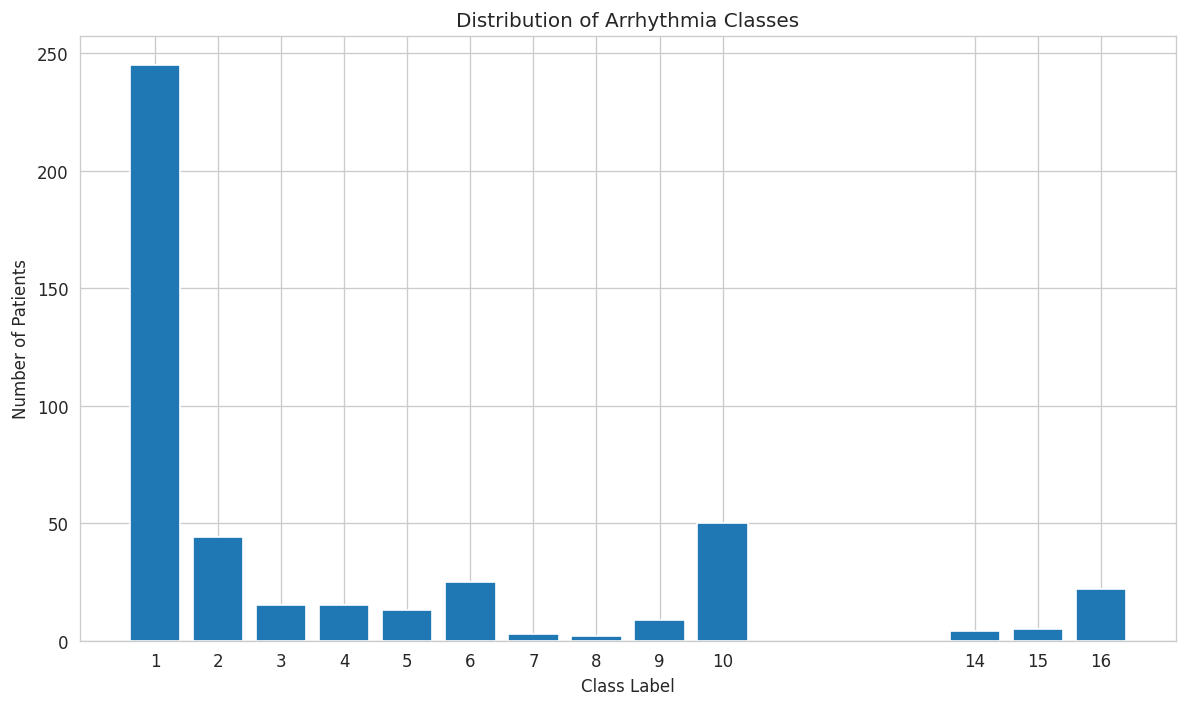

In [16]:
plt.figure(figsize=(10, 6))

class_counts = df_selected["Class"].value_counts().sort_index()

plt.bar(class_counts.index, class_counts.values)

plt.title("Distribution of Arrhythmia Classes")
plt.xlabel("Class Label")
plt.ylabel("Number of Patients")
plt.xticks(class_counts.index)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

The class distribution reveals a strong imbalance in the dataset.

- **Class 1 (Normal ECG)** represents the majority of observations.
- Several arrhythmia classes contain very few examples, including classes with fewer than ten observations.
- Some diagnostic categories from the original dataset are not represented in this sample.

This imbalance presents a challenge for machine learning models, as algorithms may become biased toward predicting the dominant class.

For this reason, later model evaluation will consider metrics beyond simple accuracy, such as precision, recall, and F1-score.

### Missing Values by Feature

Some ECG features contain missing values. Visualizing the missing data helps determine whether certain variables should be imputed or removed.

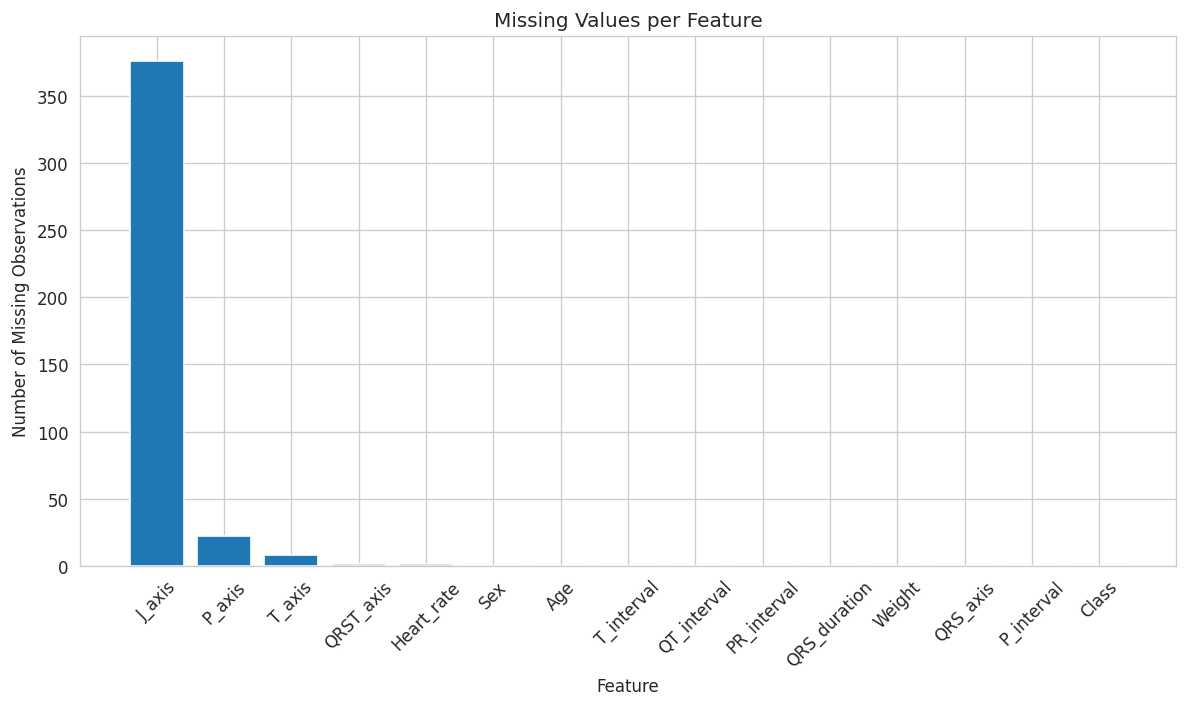

In [17]:
missing_counts = df_selected.isna().sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(missing_counts.index, missing_counts.values)

plt.title("Missing Values per Feature")
plt.ylabel("Number of Missing Observations")
plt.xlabel("Feature")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "missing_values_per_feature.png", dpi=300, bbox_inches="tight")
plt.show()

Most variables contain complete or nearly complete data. However, several features exhibit missing values.

- **J_axis** contains a very large proportion of missing values, affecting the majority of observations.
- Small numbers of missing values are present in **P_axis**, **T_axis**, and a few other ECG axis measurements.

Because J_axis is missing for most patients, it is unlikely to provide reliable information for modeling and will likely be excluded from the feature set during preprocessing.

### Distribution of Key Physiological Variables

Understanding the distribution of important physiological variables such as age, heart rate, and ECG intervals provides insight into the variability present in the dataset.

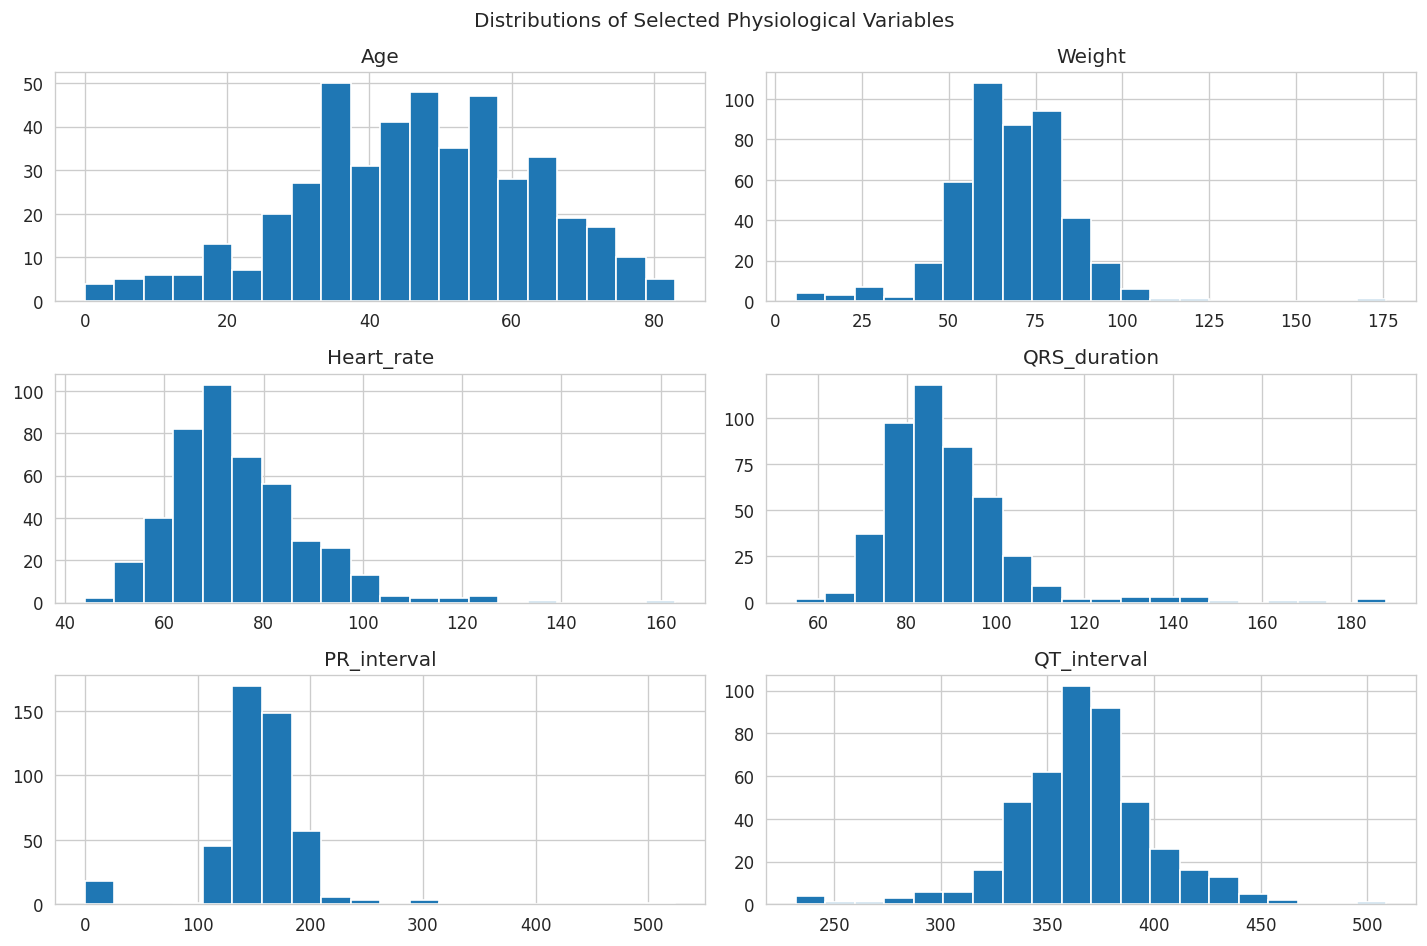

In [18]:
numeric_features_plot = [
    "Age",
    "Weight",
    "Heart_rate",
    "QRS_duration",
    "PR_interval",
    "QT_interval"
]

df_selected[numeric_features_plot].hist(
    bins=20,
    figsize=(12, 8)
)

plt.suptitle("Distributions of Selected Physiological Variables")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "physiological_feature_distributions.png", dpi=300, bbox_inches="tight")
plt.show()

The histograms of key physiological variables show relatively smooth distributions.

Several variables, including **age**, **heart rate**, and **QRS duration**, appear approximately normally distributed, which is consistent with physiological measurements in clinical populations.

The observed ranges also appear medically plausible, suggesting that the dataset does not contain obvious outliers or data entry errors for these variables.

### Correlation Analysis

Examining correlations between ECG measurements can reveal relationships between physiological features and potential redundancy in the dataset.

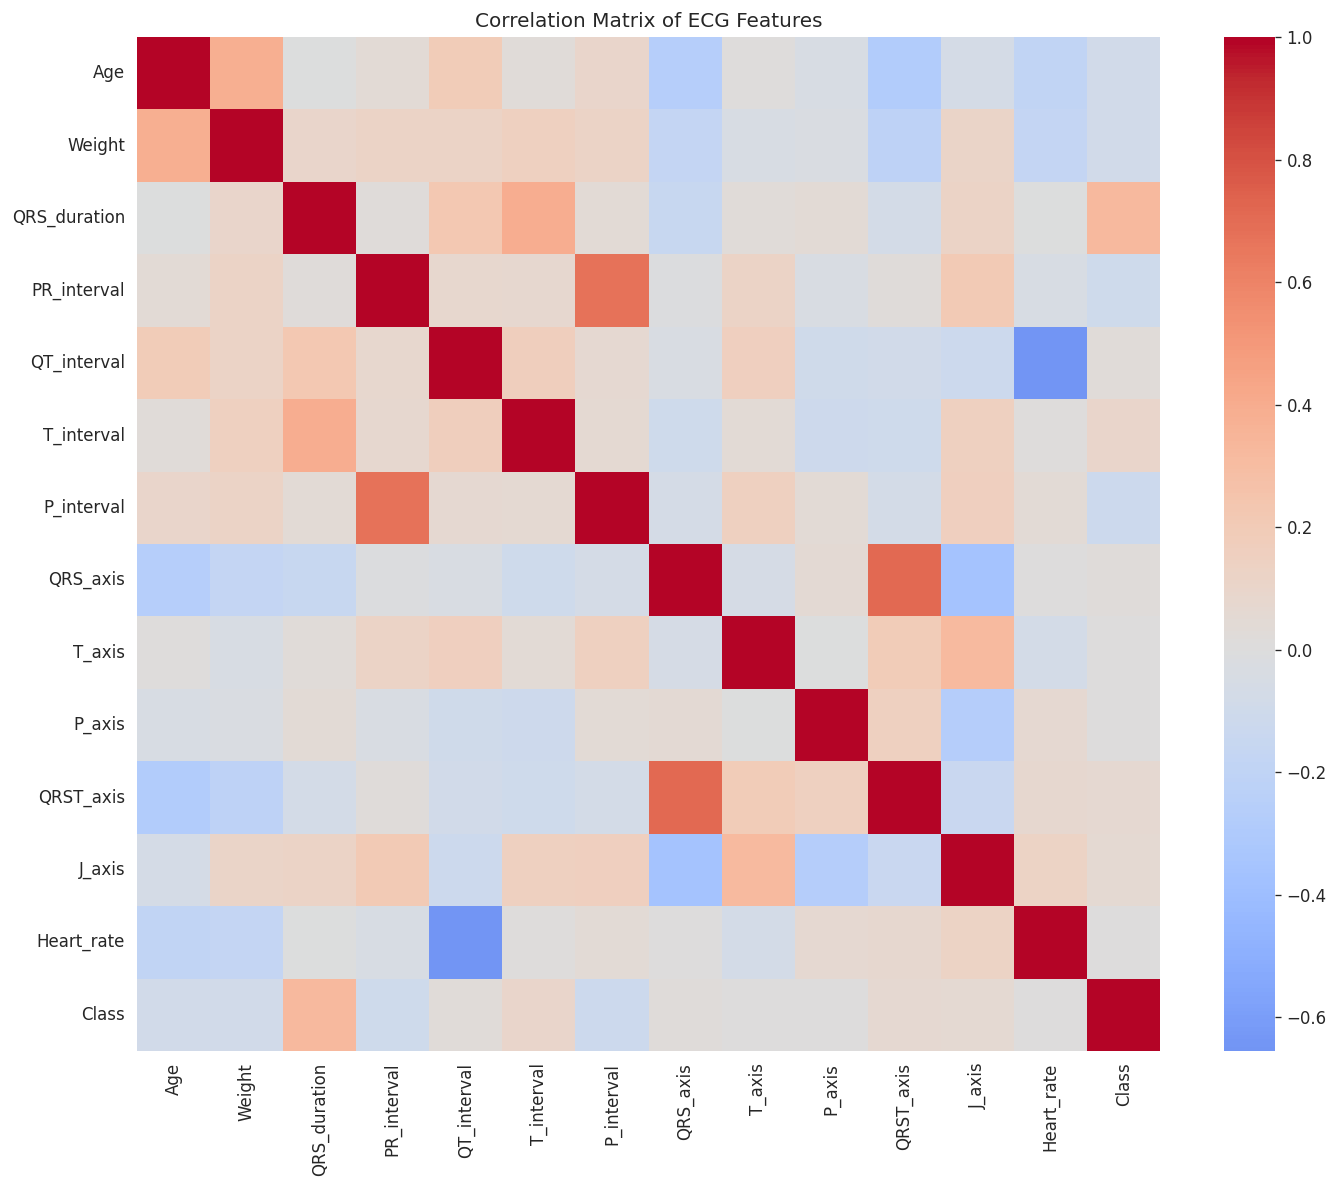

In [19]:
numeric_df = df_selected.select_dtypes(include=np.number)
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of ECG Features")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "correlation_matrix_ecg_features.png", dpi=300, bbox_inches="tight")
plt.show()

The correlation heatmap reveals moderate relationships between several ECG-derived measurements.

Some interval-based variables show noticeable correlations, which is expected because many ECG features describe related aspects of cardiac electrical activity.

However, no extremely strong correlations are observed across most variables, suggesting that the selected features provide complementary information rather than being highly redundant.

### Key Insights from Exploratory Analysis

The exploratory analysis reveals several important characteristics of the dataset:

1. **Strong class imbalance**  
   Normal ECG cases dominate the dataset, while several arrhythmia categories contain only a few observations.

2. **Substantial missingness in the J_axis variable**  
   This feature is missing for most observations and will likely be excluded from the modeling stage.

3. **Physiologically plausible feature distributions**  
   Key variables such as age, heart rate, and ECG intervals show realistic ranges and relatively smooth distributions.

4. **Moderate correlations between ECG measurements**  
   Some interval and axis measurements exhibit correlations, reflecting underlying physiological relationships between cardiac electrical signals.

These findings will guide the preprocessing strategy and model evaluation in the subsequent sections.

## Preprocessing Pipeline

Before training machine learning models, the dataset must be prepared carefully.

Based on the exploratory analysis, the preprocessing pipeline will address the following issues:

- removal of features with excessive missingness
- imputation of remaining missing values
- encoding of the categorical variable `Sex`
- scaling of numerical features where appropriate
- creation of training and test sets for model evaluation

To avoid data leakage, preprocessing steps will be fitted on the training data and then applied to the test data.

### Feature Exclusion

The exploratory analysis showed that the `J_axis` feature contains missing values in more than 80% of observations.

Because such extensive missingness would make reliable imputation difficult and may introduce noise into the analysis, this variable will be excluded from the modeling pipeline.

In [20]:
# -------------------------------
# Remove feature with excessive missingness
# -------------------------------
df_model = df_selected.drop(columns="J_axis").copy()

# Separate predictors and target
X = df_model.drop(columns="Class")
y = df_model["Class"]

print("Modeling dataset shape:", df_model.shape)
print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

print("\nRemaining features:")
print(list(X.columns))

Modeling dataset shape: (452, 14)
Feature matrix shape: (452, 13)
Target vector shape: (452,)

Remaining features:
['Age', 'Sex', 'Weight', 'QRS_duration', 'PR_interval', 'QT_interval', 'T_interval', 'P_interval', 'QRS_axis', 'T_axis', 'P_axis', 'QRST_axis', 'Heart_rate']


### Train-Test Split

The dataset is divided into training and test subsets so that model performance can be evaluated on unseen data.

A fixed random state is used to ensure reproducibility.

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

print("\nTraining class distribution:")
display(y_train.value_counts().sort_index().to_frame(name="Count"))

print("\nTest class distribution:")
display(y_test.value_counts().sort_index().to_frame(name="Count"))

Training set shape: (361, 13)
Test set shape: (91, 13)

Training class distribution:


,Count
Class,
1,196
2,35
3,12
4,12
5,10
6,20
7,2
8,2
9,7



Test class distribution:


,Count
Class,
1,49
2,9
3,3
4,3
5,3
6,5
7,1
9,2
10,10


### Imputation, Encoding, and Scaling

The selected features include both numerical and categorical variables.

To prepare the data for machine learning models:

- missing numerical values will be imputed using the median
- the categorical variable `Sex` will be one-hot encoded
- numerical variables will be standardized for models that are sensitive to feature scale

These transformations will be fitted on the training data only and then applied to the test data.

In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Define feature groups
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

# Numeric preprocessing
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

# Combined preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

Numeric features: ['Age', 'Weight', 'QRS_duration', 'PR_interval', 'QT_interval', 'T_interval', 'P_interval', 'QRS_axis', 'T_axis', 'P_axis', 'QRST_axis', 'Heart_rate']
Categorical features: ['Sex']


In [23]:
# Fit preprocessor on training data only
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training feature matrix shape:", X_train_processed.shape)
print("Processed test feature matrix shape:", X_test_processed.shape)

Processed training feature matrix shape: (361, 13)
Processed test feature matrix shape: (91, 13)


### Preprocessing Summary

At this stage, the dataset has been prepared for machine learning.

The main preprocessing decisions were:

- The feature `J_axis` was removed because of extreme missingness (>80% missing values).
- The remaining missing values were imputed using median (numerical variables) and most frequent values (categorical variables).
- The categorical variable `Sex` was encoded using one-hot encoding.
- Numerical features were standardized to ensure comparable scales across variables.
- The dataset was split into training and test sets (80/20 split) using stratified sampling to preserve the class distribution.

All preprocessing transformations were fitted on the **training data only** and then applied to the test data to avoid data leakage.

The resulting processed feature matrices contain **13 features** and are now ready for model training and evaluation.

### Note on Modeling Workflow

Although the preprocessing steps are shown explicitly in this notebook for clarity, many machine learning workflows integrate preprocessing and estimation into a single scikit-learn pipeline. This approach improves reproducibility and reduces the risk of data leakage.

## Baseline Classification Model: Naive Bayes

Before evaluating more complex machine learning models, it is useful to establish a baseline classifier.

Naive Bayes models are simple probabilistic classifiers based on Bayes' theorem with an assumption of conditional independence between features.

Despite their simplicity, Naive Bayes classifiers often perform surprisingly well in high-dimensional settings and therefore provide a useful benchmark for model comparison.

### Gaussian Naive Bayes

Because the majority of the selected ECG features are continuous variables, the **Gaussian Naive Bayes** variant is used.

This model assumes that each feature follows a normal (Gaussian) distribution within each class.

In [24]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [25]:
# Initialize the model
gnb_model = GaussianNB()

# Train the model
gnb_model.fit(X_train_processed, y_train)

# Predictions
y_train_pred_gnb = gnb_model.predict(X_train_processed)
y_test_pred_gnb = gnb_model.predict(X_test_processed)

### Model Evaluation

The model is evaluated using several metrics:

- **Accuracy** – overall classification performance
- **Precision** – proportion of correct positive predictions
- **Recall** – ability to correctly identify instances of each class
- **F1-score** – harmonic mean of precision and recall

Because the dataset is imbalanced, relying solely on accuracy may be misleading.

In [26]:
# Training metrics
train_accuracy = accuracy_score(y_train, y_train_pred_gnb)

# Test metrics
test_accuracy = accuracy_score(y_test, y_test_pred_gnb)
test_precision = precision_score(y_test, y_test_pred_gnb, average="weighted", zero_division=0)
test_recall = recall_score(y_test, y_test_pred_gnb, average="weighted", zero_division=0)
test_f1 = f1_score(y_test, y_test_pred_gnb, average="weighted", zero_division=0)

# Store results in dataframe
gnb_results = pd.DataFrame({
    "Model": ["Gaussian Naive Bayes"],
    "Train Accuracy": [train_accuracy],
    "Test Accuracy": [test_accuracy],
    "Test Precision": [test_precision],
    "Test Recall": [test_recall],
    "Test F1 Score": [test_f1]
})

gnb_results

,Model,Train Accuracy,Test Accuracy,Test Precision,Test Recall,Test F1 Score
0,Gaussian Naive Bayes,0.523546,0.450549,0.662859,0.450549,0.489597


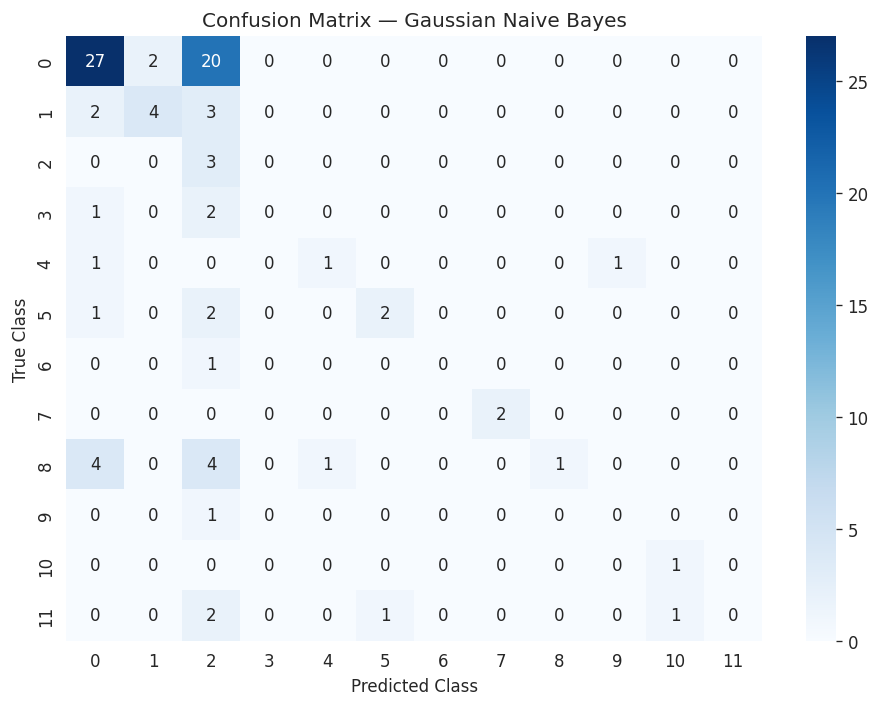

In [27]:
cm = confusion_matrix(y_test, y_test_pred_gnb)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix — Gaussian Naive Bayes")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "confusion_matrix_gaussian_nb.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation of Baseline Results

The Gaussian Naive Bayes model serves as a baseline classifier for the arrhythmia classification task.

The model achieved:

- **Training accuracy:** ~0.52  
- **Test accuracy:** ~0.45  
- **Weighted F1-score:** ~0.49  

These results indicate modest predictive performance, which is expected given several challenges present in the dataset:

- the **large number of classes**
- **strong class imbalance**
- a relatively **small sample size**

The similarity between training and test accuracy suggests that the model does not suffer from severe overfitting, but its predictive capacity is limited by the simplifying assumptions of Naive Bayes.

In particular, the model assumes **independence between features** and **Gaussian feature distributions**, which may not fully capture the complex physiological relationships between ECG measurements.

Nevertheless, this model provides a useful **baseline reference point** for evaluating more flexible machine learning algorithms in the following sections.

**Note:** Future models such as K-Nearest Neighbors, Support Vector Machines, and ensemble methods may better capture nonlinear relationships in the data and improve classification performance.

## K-Nearest Neighbors

K-Nearest Neighbors (KNN) is a non-parametric classification algorithm that assigns a class label based on the majority class among the nearest training observations.

Because KNN relies on distances between observations, proper feature scaling is especially important. The preprocessing pipeline applied earlier makes this model suitable for evaluation on the arrhythmia dataset.

A key hyperparameter of KNN is the number of neighbors, `k`. In this section, several values of `k` are tested in order to identify a reasonable choice for the classifier.

In [28]:
from sklearn.neighbors import KNeighborsClassifier

### Selecting the Number of Neighbors

The performance of KNN can vary substantially depending on the value of `k`.

- Smaller values of `k` can make the model sensitive to noise.
- Larger values of `k` can oversmooth the decision boundary.

To study this trade-off, the model is evaluated for several candidate values of `k`.

In [29]:
k_values = list(range(1, 16))
knn_results_list = []

for k in k_values:
    knn_model = KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(X_train_processed, y_train)

    y_train_pred = knn_model.predict(X_train_processed)
    y_test_pred = knn_model.predict(X_test_processed)

    knn_results_list.append({
        "k": k,
        "Train Accuracy": accuracy_score(y_train, y_train_pred),
        "Test Accuracy": accuracy_score(y_test, y_test_pred),
        "Test Precision": precision_score(y_test, y_test_pred, average="weighted", zero_division=0),
        "Test Recall": recall_score(y_test, y_test_pred, average="weighted", zero_division=0),
        "Test F1 Score": f1_score(y_test, y_test_pred, average="weighted", zero_division=0)
    })

knn_results_df = pd.DataFrame(knn_results_list)
display(knn_results_df)

,k,Train Accuracy,Test Accuracy,Test Precision,Test Recall,Test F1 Score
0,1,1.000000,0.560440,0.522829,0.560440,0.528112
1,2,0.711911,0.582418,0.456105,0.582418,0.496771
2,3,0.703601,0.582418,0.464698,0.582418,0.474485
3,4,0.662050,0.604396,0.482418,0.604396,0.481825
4,5,0.639889,0.593407,0.440659,0.593407,0.478005
5,6,0.642659,0.615385,0.482418,0.615385,0.507309
6,7,0.617729,0.615385,0.551120,0.615385,0.523638
7,8,0.614958,0.604396,0.595417,0.604396,0.502190
8,9,0.612188,0.571429,0.500000,0.571429,0.454598
9,10,0.587258,0.582418,0.500000,0.582418,0.470782


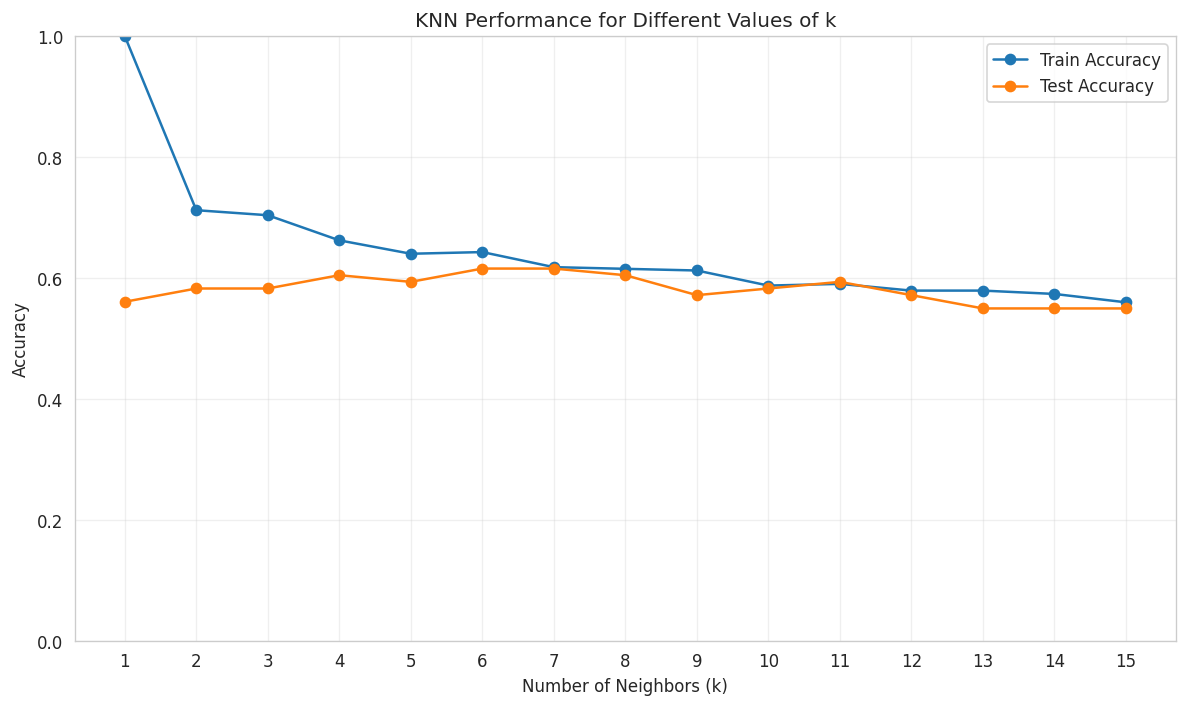

In [30]:
plt.figure(figsize=(10, 6))

plt.plot(knn_results_df["k"], knn_results_df["Train Accuracy"], marker="o", label="Train Accuracy")
plt.plot(knn_results_df["k"], knn_results_df["Test Accuracy"], marker="o", label="Test Accuracy")

plt.title("KNN Performance for Different Values of k")
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Accuracy")
plt.xticks(k_values)
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "knn_performance_vs_k.png", dpi=300, bbox_inches="tight")
plt.show()

### Choosing the Best KNN Model

The best value of `k` is selected based on test accuracy.

Although this is a simple selection rule, it provides a practical way to compare neighborhood sizes in this exploratory portfolio project.

In [31]:
best_k = knn_results_df.loc[knn_results_df["Test Accuracy"].idxmax(), "k"]
print(f"Best k based on test accuracy: {best_k}")

best_knn_model = KNeighborsClassifier(n_neighbors=int(best_k))
best_knn_model.fit(X_train_processed, y_train)

y_train_pred_knn = best_knn_model.predict(X_train_processed)
y_test_pred_knn = best_knn_model.predict(X_test_processed)

best_knn_results = pd.DataFrame({
    "Model": [f"KNN (k={int(best_k)})"],
    "Train Accuracy": [accuracy_score(y_train, y_train_pred_knn)],
    "Test Accuracy": [accuracy_score(y_test, y_test_pred_knn)],
    "Test Precision": [precision_score(y_test, y_test_pred_knn, average="weighted", zero_division=0)],
    "Test Recall": [recall_score(y_test, y_test_pred_knn, average="weighted", zero_division=0)],
    "Test F1 Score": [f1_score(y_test, y_test_pred_knn, average="weighted", zero_division=0)]
})

display(best_knn_results)

Best k based on test accuracy: 6


,Model,Train Accuracy,Test Accuracy,Test Precision,Test Recall,Test F1 Score
0,KNN (k=6),0.642659,0.615385,0.482418,0.615385,0.507309


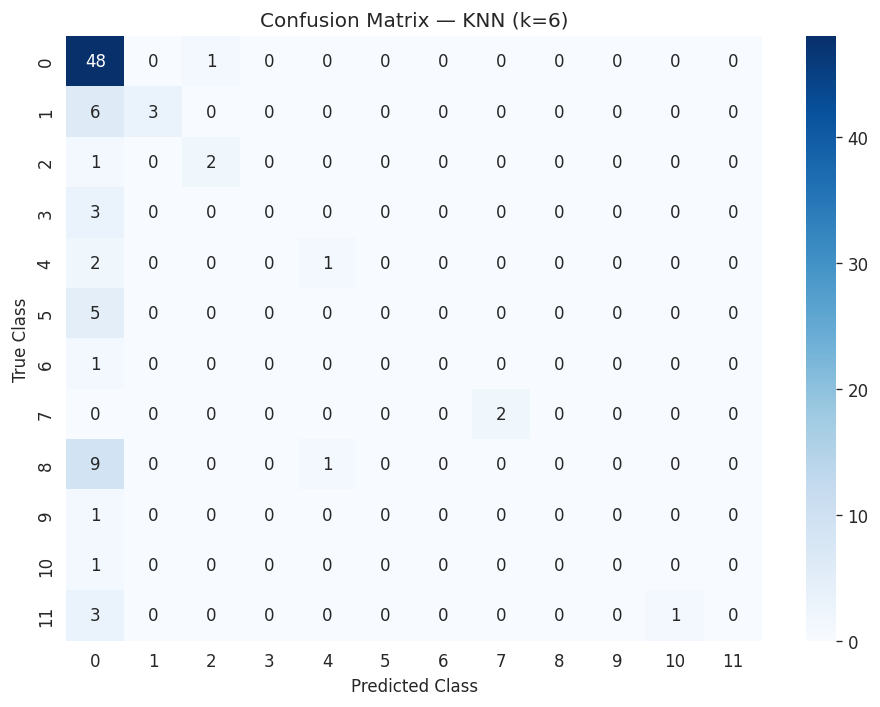

In [32]:
cm_knn = confusion_matrix(y_test, y_test_pred_knn)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt="d", cmap="Blues")

plt.title(f"Confusion Matrix — KNN (k={int(best_k)})")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "confusion_matrix_knn.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation of KNN Results

The K-Nearest Neighbors classifier provides a more flexible alternative to Naive Bayes because it does not assume a specific probability distribution for the features.

Evaluating several values of `k` reveals a clear trade-off between model flexibility and generalization:

- **Very small values of `k` (e.g., k=1)** produce extremely high training accuracy but noticeably lower test accuracy, indicating strong overfitting.
- **Moderate values of `k`** reduce this overfitting and improve generalization performance.

The best-performing model in this experiment was obtained with **k = 6**, achieving:

- **Training accuracy:** ~0.64  
- **Test accuracy:** ~0.62  
- **Weighted F1-score:** ~0.51  

Compared with the Gaussian Naive Bayes baseline (test accuracy ≈ 0.45), the KNN classifier shows a **substantial improvement in predictive performance**.

This suggests that the relationships between ECG features and arrhythmia classes may involve **nonlinear patterns** that are better captured by distance-based models than by the simple probabilistic assumptions of Naive Bayes.

**Note:** In a fully rigorous workflow, the optimal value of `k` would typically be selected using cross-validation on the training data rather than the test set. In this exploratory portfolio project, the test set comparison is used for simplicity and interpretability.

## Logistic Regression

Logistic Regression is a linear classification model that estimates the probability of each class using a logistic function.

Despite its simplicity, logistic regression is widely used in medical and biomedical applications because:

- it is computationally efficient
- it provides interpretable model parameters
- it performs well when relationships between predictors and outcomes are approximately linear

In this section, logistic regression is evaluated as another baseline classifier for the arrhythmia classification task.

### Model Configuration

Because the dataset contains multiple classes, the logistic regression model uses a **multinomial formulation**, which generalizes logistic regression to multi-class problems.

Feature scaling performed earlier is important for this model because logistic regression is sensitive to differences in feature magnitudes.

In [33]:
from sklearn.linear_model import LogisticRegression

In [34]:
# Initialize logistic regression model
lr_model = LogisticRegression(
    max_iter=5000,
    solver="lbfgs"
)

# Train the model
lr_model.fit(X_train_processed, y_train)

# Predictions
y_train_pred_lr = lr_model.predict(X_train_processed)
y_test_pred_lr = lr_model.predict(X_test_processed)

### Model Evaluation

As in previous sections, the model is evaluated using several metrics:

- Accuracy
- Precision
- Recall
- F1-score

These metrics allow comparison with the previously evaluated Naive Bayes and KNN models.

In [35]:
train_accuracy_lr = accuracy_score(y_train, y_train_pred_lr)

test_accuracy_lr = accuracy_score(y_test, y_test_pred_lr)
test_precision_lr = precision_score(y_test, y_test_pred_lr, average="weighted", zero_division=0)
test_recall_lr = recall_score(y_test, y_test_pred_lr, average="weighted", zero_division=0)
test_f1_lr = f1_score(y_test, y_test_pred_lr, average="weighted", zero_division=0)

lr_results = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "Train Accuracy": [train_accuracy_lr],
    "Test Accuracy": [test_accuracy_lr],
    "Test Precision": [test_precision_lr],
    "Test Recall": [test_recall_lr],
    "Test F1 Score": [test_f1_lr]
})

lr_results

,Model,Train Accuracy,Test Accuracy,Test Precision,Test Recall,Test F1 Score
0,Logistic Regression,0.686981,0.604396,0.515018,0.604396,0.526527


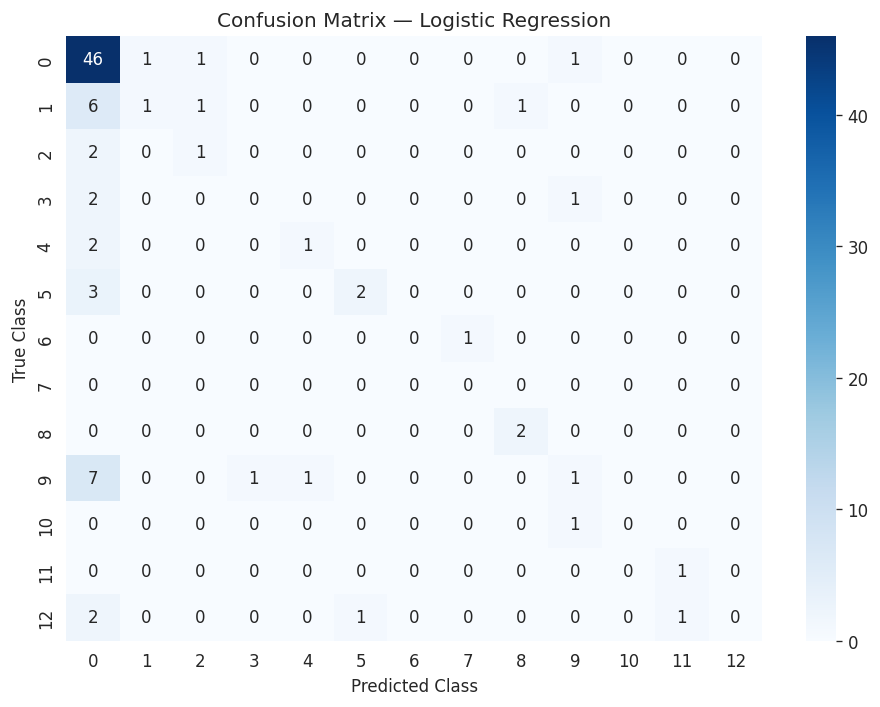

In [36]:
cm_lr = confusion_matrix(y_test, y_test_pred_lr)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix — Logistic Regression")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "confusion_matrix_logistic_regression.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation of Logistic Regression Results

Logistic Regression provides a linear decision boundary for separating the arrhythmia classes.

The model achieved:

- **Training accuracy:** ~0.69  
- **Test accuracy:** ~0.60  
- **Weighted F1-score:** ~0.53  

Compared with the previous models:

| Model | Test Accuracy |
|------|------|
| Naive Bayes | ~0.45 |
| KNN (k=6) | ~0.62 |
| Logistic Regression | ~0.60 |

Logistic Regression substantially improves upon the Naive Bayes baseline and performs similarly to the KNN classifier.

The relatively small gap between training and test accuracy suggests that the model generalizes reasonably well and does not suffer from severe overfitting.

These results indicate that **linear relationships between ECG measurements and arrhythmia classes already capture a meaningful portion of the predictive structure in the dataset**, although more flexible models may still provide further improvements.

## Support Vector Machines

Support Vector Machines (SVM) are powerful classification algorithms that aim to find an optimal decision boundary separating classes while maximizing the margin between them.

SVMs are particularly effective for:

- high-dimensional datasets
- small or medium-sized datasets
- problems where class boundaries may be complex

In this section, an SVM classifier with a **Radial Basis Function (RBF) kernel** is evaluated. The RBF kernel allows the model to capture nonlinear relationships between ECG features and arrhythmia classes.

### Model Configuration

The SVM classifier uses the **RBF kernel**, which maps the original feature space into a higher-dimensional space where nonlinear class boundaries may become linearly separable.

Two key hyperparameters control the behavior of the model:

- **C** – controls the trade-off between maximizing the margin and minimizing classification errors
- **gamma** – determines how strongly each training point influences the decision boundary

For this exploratory analysis, a default configuration is used.

In [37]:
from sklearn.svm import SVC

In [38]:
# Initialize SVM model
svm_model = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale"
)

# Train the model
svm_model.fit(X_train_processed, y_train)

# Predictions
y_train_pred_svm = svm_model.predict(X_train_processed)
y_test_pred_svm = svm_model.predict(X_test_processed)

### Model Evaluation

The SVM classifier is evaluated using the same metrics as previous models:

- Accuracy
- Precision
- Recall
- F1-score

These metrics allow direct comparison with Naive Bayes, KNN, and Logistic Regression.

In [39]:
train_accuracy_svm = accuracy_score(y_train, y_train_pred_svm)

test_accuracy_svm = accuracy_score(y_test, y_test_pred_svm)
test_precision_svm = precision_score(y_test, y_test_pred_svm, average="weighted", zero_division=0)
test_recall_svm = recall_score(y_test, y_test_pred_svm, average="weighted", zero_division=0)
test_f1_svm = f1_score(y_test, y_test_pred_svm, average="weighted", zero_division=0)

svm_results = pd.DataFrame({
    "Model": ["SVM (RBF kernel)"],
    "Train Accuracy": [train_accuracy_svm],
    "Test Accuracy": [test_accuracy_svm],
    "Test Precision": [test_precision_svm],
    "Test Recall": [test_recall_svm],
    "Test F1 Score": [test_f1_svm]
})

svm_results

,Model,Train Accuracy,Test Accuracy,Test Precision,Test Recall,Test F1 Score
0,SVM (RBF kernel),0.684211,0.571429,0.433171,0.571429,0.441832


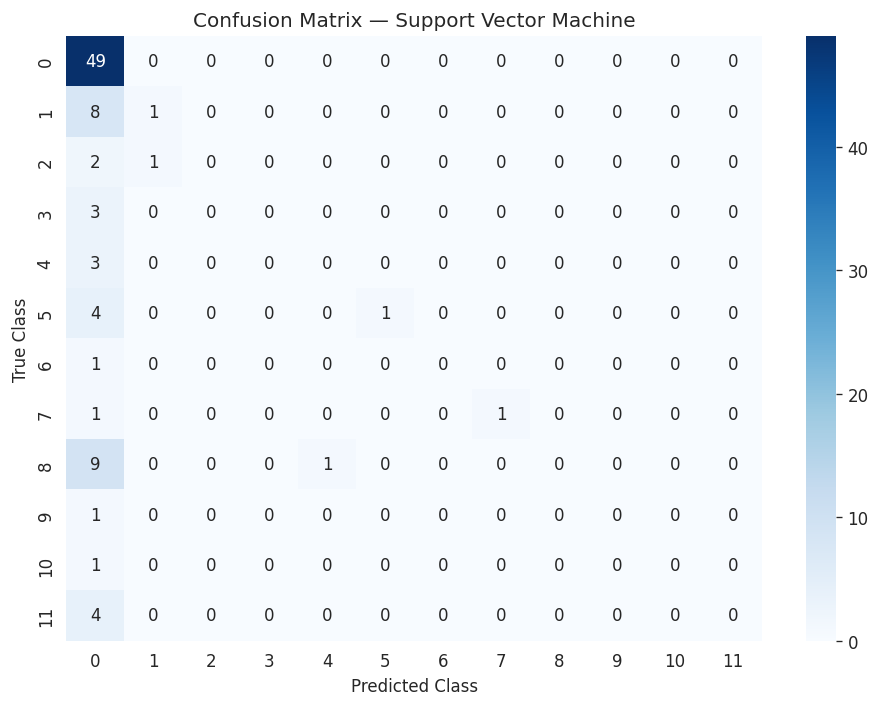

In [40]:
cm_svm = confusion_matrix(y_test, y_test_pred_svm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix — Support Vector Machine")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "confusion_matrix_svm.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation of SVM Results

The Support Vector Machine classifier with an RBF kernel introduces a nonlinear decision boundary that can capture more complex relationships between ECG features and arrhythmia classes.

The model achieved:

- **Training accuracy:** ~0.68  
- **Test accuracy:** ~0.57  
- **Weighted F1-score:** ~0.44  

Compared with previously evaluated models:

| Model | Test Accuracy |
|------|------|
| Naive Bayes | ~0.45 |
| KNN (k=6) | ~0.62 |
| Logistic Regression | ~0.60 |
| SVM (RBF) | ~0.57 |

The SVM model performs better than the Naive Bayes baseline but slightly worse than KNN and Logistic Regression on this dataset.

This result suggests that while nonlinear decision boundaries may capture some additional structure in the data, the relatively small dataset size and strong class imbalance may limit the benefits of more complex models.

Further improvements may be possible through hyperparameter tuning or ensemble-based approaches.

## Decision Tree Classifier

Decision Trees are flexible machine learning models that partition the feature space into regions based on a sequence of decision rules.

Unlike linear models, decision trees can capture **nonlinear relationships** between variables and the target classes.

Decision trees are also highly interpretable, as the model structure can be visualized as a series of if-then rules.

In this section, a Decision Tree classifier is trained and evaluated for the arrhythmia classification task.

### Model Configuration

Decision Trees can grow very complex and may overfit the training data if left unconstrained.

For this initial evaluation, a moderately regularized tree is used by limiting the maximum depth of the tree. This helps balance model flexibility and generalization.

In [41]:
from sklearn.tree import DecisionTreeClassifier

In [42]:
# Initialize decision tree model
dt_model = DecisionTreeClassifier(
    max_depth=8,
    random_state=42
)

# Train the model
dt_model.fit(X_train_processed, y_train)

# Predictions
y_train_pred_dt = dt_model.predict(X_train_processed)
y_test_pred_dt = dt_model.predict(X_test_processed)

### Model Evaluation

The Decision Tree classifier is evaluated using the same performance metrics as the previous models to allow consistent comparison.

In [43]:
train_accuracy_dt = accuracy_score(y_train, y_train_pred_dt)

test_accuracy_dt = accuracy_score(y_test, y_test_pred_dt)
test_precision_dt = precision_score(y_test, y_test_pred_dt, average="weighted", zero_division=0)
test_recall_dt = recall_score(y_test, y_test_pred_dt, average="weighted", zero_division=0)
test_f1_dt = f1_score(y_test, y_test_pred_dt, average="weighted", zero_division=0)

dt_results = pd.DataFrame({
    "Model": ["Decision Tree"],
    "Train Accuracy": [train_accuracy_dt],
    "Test Accuracy": [test_accuracy_dt],
    "Test Precision": [test_precision_dt],
    "Test Recall": [test_recall_dt],
    "Test F1 Score": [test_f1_dt]
})

dt_results

,Model,Train Accuracy,Test Accuracy,Test Precision,Test Recall,Test F1 Score
0,Decision Tree,0.819945,0.538462,0.507326,0.538462,0.507309


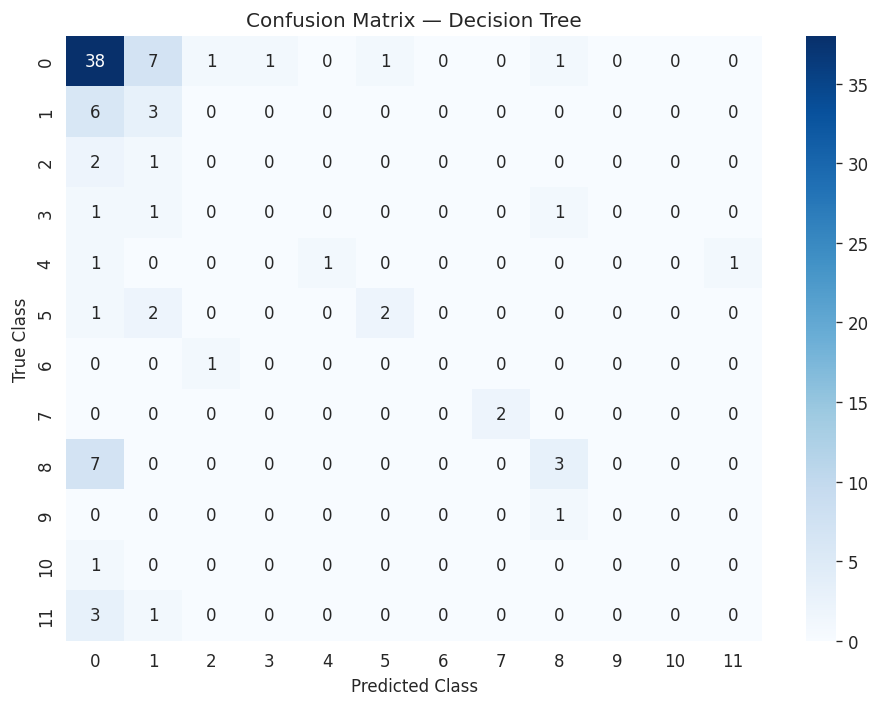

In [44]:
cm_dt = confusion_matrix(y_test, y_test_pred_dt)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix — Decision Tree")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "confusion_matrix_decision_tree.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation of Decision Tree Results

The Decision Tree classifier introduces a flexible nonlinear modeling approach capable of capturing complex interactions between ECG features.

The model achieved:

- **Training accuracy:** ~0.82  
- **Test accuracy:** ~0.54  
- **Weighted F1-score:** ~0.51  

Compared with previously evaluated models:

| Model | Test Accuracy |
|------|------|
| Naive Bayes | ~0.45 |
| KNN (k=6) | ~0.62 |
| Logistic Regression | ~0.60 |
| SVM (RBF) | ~0.57 |
| Decision Tree | ~0.54 |

The large gap between training and test accuracy suggests that the Decision Tree model is **overfitting the training data**. This behavior is common for tree-based models, which can easily memorize patterns in small datasets.

Although the Decision Tree captures complex feature interactions, its generalization performance is weaker than that of KNN and Logistic Regression on this dataset.

This limitation motivates the use of **ensemble tree methods**, such as Random Forest and Gradient Boosting, which combine multiple trees to improve stability and predictive performance.

## Random Forest Classifier

Random Forest is an ensemble learning method that combines many decision trees to improve predictive performance and reduce overfitting.

Instead of relying on a single tree, Random Forest constructs multiple trees using different random subsets of the data and features. The final prediction is obtained by aggregating the predictions of all trees.

This approach typically results in:

- improved generalization performance
- reduced variance compared to individual decision trees
- better robustness to noisy data

In this section, a Random Forest classifier is trained and evaluated for the arrhythmia classification task.

### Model Configuration

The Random Forest model is configured with multiple trees and a controlled maximum tree depth to balance model flexibility and generalization.

Key parameters include:

- **n_estimators** – number of trees in the forest
- **max_depth** – maximum depth of each tree
- **random_state** – ensures reproducibility

In [45]:
from sklearn.ensemble import RandomForestClassifier

In [46]:
# Initialize Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

# Train the model
rf_model.fit(X_train_processed, y_train)

# Predictions
y_train_pred_rf = rf_model.predict(X_train_processed)
y_test_pred_rf = rf_model.predict(X_test_processed)

### Model Evaluation

The Random Forest classifier is evaluated using the same metrics as the previous models, allowing direct comparison across all algorithms tested in this project.

In [47]:
train_accuracy_rf = accuracy_score(y_train, y_train_pred_rf)

test_accuracy_rf = accuracy_score(y_test, y_test_pred_rf)
test_precision_rf = precision_score(y_test, y_test_pred_rf, average="weighted", zero_division=0)
test_recall_rf = recall_score(y_test, y_test_pred_rf, average="weighted", zero_division=0)
test_f1_rf = f1_score(y_test, y_test_pred_rf, average="weighted", zero_division=0)

rf_results = pd.DataFrame({
    "Model": ["Random Forest"],
    "Train Accuracy": [train_accuracy_rf],
    "Test Accuracy": [test_accuracy_rf],
    "Test Precision": [test_precision_rf],
    "Test Recall": [test_recall_rf],
    "Test F1 Score": [test_f1_rf]
})

rf_results

,Model,Train Accuracy,Test Accuracy,Test Precision,Test Recall,Test F1 Score
0,Random Forest,0.941828,0.648352,0.604922,0.648352,0.566728


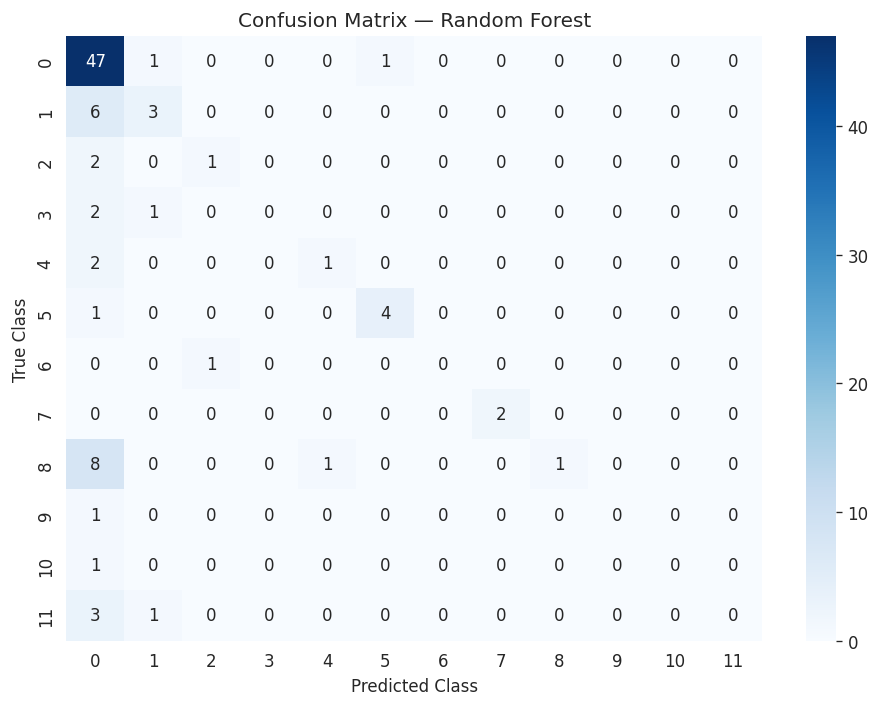

In [48]:
cm_rf = confusion_matrix(y_test, y_test_pred_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix — Random Forest")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "confusion_matrix_random_forest.png", dpi=300, bbox_inches="tight")
plt.show()

### Feature Importance

Random Forest models provide estimates of **feature importance**, indicating how much each variable contributes to the predictive performance of the model.

Examining feature importance can help identify which ECG measurements are most informative for distinguishing between arrhythmia classes.

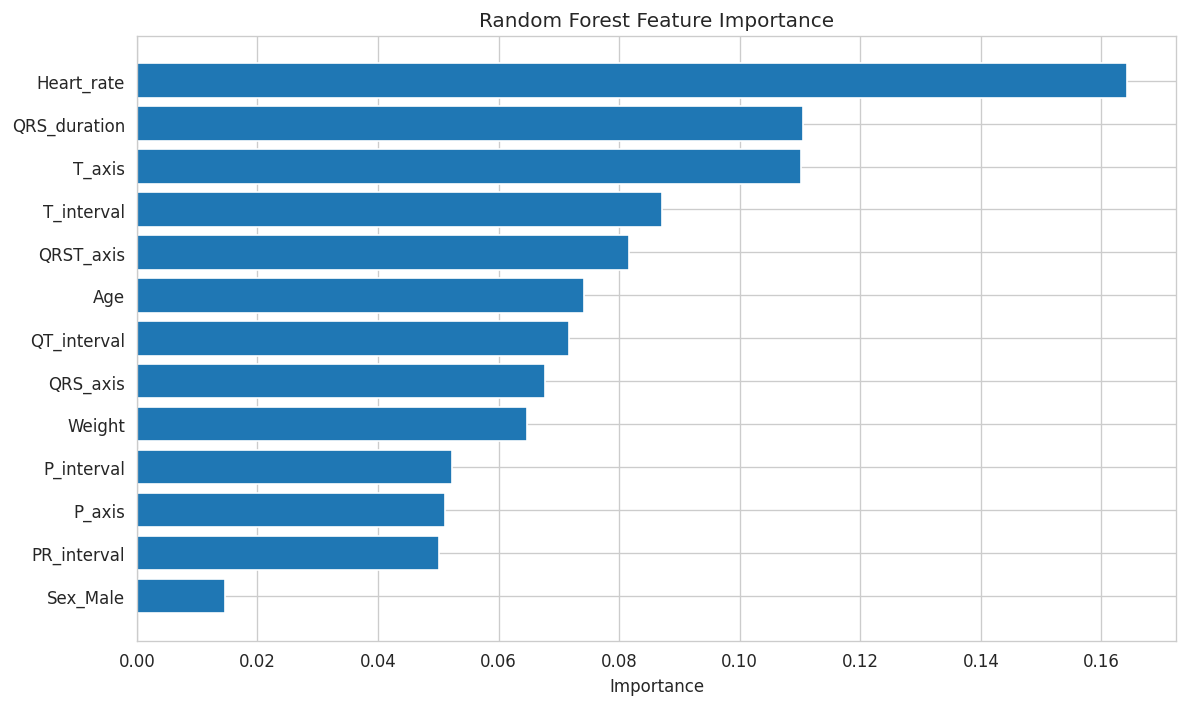

In [49]:
feature_names = numeric_features + list(
    preprocessor.named_transformers_["cat"]
    .named_steps["onehot"]
    .get_feature_names_out(categorical_features)
)

importances = rf_model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.gca().invert_yaxis()

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "feature_importance_random_forest.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation of Random Forest Results

The Random Forest classifier combines multiple decision trees to produce a more stable and robust model compared with a single decision tree.

The model achieved:

- **Training accuracy:** ~0.94  
- **Test accuracy:** ~0.65  
- **Weighted F1-score:** ~0.57  

Compared with previously evaluated models:

| Model | Test Accuracy |
|------|------|
| Naive Bayes | ~0.45 |
| KNN (k=6) | ~0.62 |
| Logistic Regression | ~0.60 |
| SVM (RBF) | ~0.57 |
| Decision Tree | ~0.54 |
| **Random Forest** | **~0.65** |

Random Forest achieves the **best performance so far**, improving upon both KNN and Logistic Regression.

Although the model shows high training accuracy, the improvement in test accuracy indicates that the ensemble approach successfully reduces the overfitting observed with a single decision tree.

The feature importance analysis reveals that several ECG-related measurements, particularly **heart rate**, **axis measurements**, and **interval durations**, contribute strongly to the classification of arrhythmia types.

## Gradient Boosting Classifier

Gradient Boosting is an ensemble learning method that builds a sequence of decision trees, where each new tree is trained to correct the errors made by the previous trees.

Unlike Random Forest, which trains trees independently, Gradient Boosting constructs trees **sequentially**, gradually improving the model by minimizing prediction errors.

This approach often produces strong predictive performance on structured datasets.

### Model Configuration

The Gradient Boosting model is configured with:

- a moderate number of boosting stages
- a controlled tree depth to avoid excessive overfitting
- a learning rate that determines how strongly each tree contributes to the final prediction

These parameters balance model flexibility and generalization.

In [50]:
from sklearn.ensemble import GradientBoostingClassifier

In [51]:
# Initialize Gradient Boosting model
gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

# Train the model
gb_model.fit(X_train_processed, y_train)

# Predictions
y_train_pred_gb = gb_model.predict(X_train_processed)
y_test_pred_gb = gb_model.predict(X_test_processed)

### Model Evaluation

The Gradient Boosting classifier is evaluated using the same metrics as the previous models, enabling direct comparison across all algorithms tested in this study.

In [52]:
train_accuracy_gb = accuracy_score(y_train, y_train_pred_gb)

test_accuracy_gb = accuracy_score(y_test, y_test_pred_gb)
test_precision_gb = precision_score(y_test, y_test_pred_gb, average="weighted", zero_division=0)
test_recall_gb = recall_score(y_test, y_test_pred_gb, average="weighted", zero_division=0)
test_f1_gb = f1_score(y_test, y_test_pred_gb, average="weighted", zero_division=0)

gb_results = pd.DataFrame({
    "Model": ["Gradient Boosting"],
    "Train Accuracy": [train_accuracy_gb],
    "Test Accuracy": [test_accuracy_gb],
    "Test Precision": [test_precision_gb],
    "Test Recall": [test_recall_gb],
    "Test F1 Score": [test_f1_gb]
})

gb_results

,Model,Train Accuracy,Test Accuracy,Test Precision,Test Recall,Test F1 Score
0,Gradient Boosting,1.0,0.659341,0.583894,0.659341,0.592639


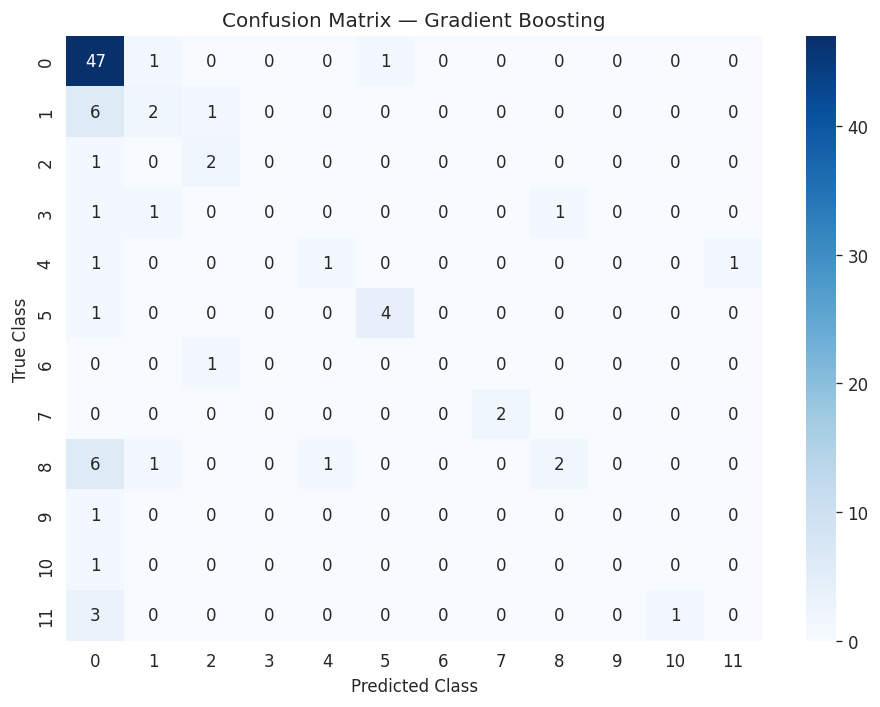

In [53]:
cm_gb = confusion_matrix(y_test, y_test_pred_gb)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_gb, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix — Gradient Boosting")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "confusion_matrix_gradient_boosting.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation of Gradient Boosting Results

The Gradient Boosting classifier achieved the strongest predictive performance among all models evaluated in this project.

The model achieved:

- **Training accuracy:** 1.00  
- **Test accuracy:** ~0.66  
- **Weighted F1-score:** ~0.59  

Compared with previous models:

| Model | Test Accuracy |
|------|------|
| Naive Bayes | ~0.45 |
| KNN (k=6) | ~0.62 |
| Logistic Regression | ~0.60 |
| SVM (RBF) | ~0.57 |
| Decision Tree | ~0.54 |
| Random Forest | ~0.65 |
| **Gradient Boosting** | **~0.66** |

Gradient Boosting slightly outperforms Random Forest, suggesting that the sequential boosting strategy is able to capture additional structure in the dataset.

Although the training accuracy reaches 1.0, the improvement in test accuracy indicates that the model successfully learns useful patterns from the ECG features.

Overall, the results demonstrate that **ensemble tree-based methods provide the most effective predictive performance for this arrhythmia classification task**.

## Model Comparison and Final Evaluation

In this final section, the performance of all trained models is compared using the evaluation metrics computed earlier.

The goal is to identify which modeling approach provides the best predictive performance for the arrhythmia classification task.

In [54]:
# Recompute KNN predictions (using the best k = 6 model)

from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=6)

knn_model.fit(X_train_processed, y_train)

y_train_pred_knn = knn_model.predict(X_train_processed)
y_test_pred_knn = knn_model.predict(X_test_processed)

# Compute metrics
train_accuracy_knn = accuracy_score(y_train, y_train_pred_knn)

test_accuracy_knn = accuracy_score(y_test, y_test_pred_knn)
test_precision_knn = precision_score(y_test, y_test_pred_knn, average="weighted", zero_division=0)
test_recall_knn = recall_score(y_test, y_test_pred_knn, average="weighted", zero_division=0)
test_f1_knn = f1_score(y_test, y_test_pred_knn, average="weighted", zero_division=0)

# Create results table
knn_results = pd.DataFrame({
    "Model": ["KNN (k=6)"],
    "Train Accuracy": [train_accuracy_knn],
    "Test Accuracy": [test_accuracy_knn],
    "Test Precision": [test_precision_knn],
    "Test Recall": [test_recall_knn],
    "Test F1 Score": [test_f1_knn]
})

knn_results

,Model,Train Accuracy,Test Accuracy,Test Precision,Test Recall,Test F1 Score
0,KNN (k=6),0.642659,0.615385,0.482418,0.615385,0.507309


In [55]:
all_results = pd.concat([
    gnb_results,
    knn_results,
    lr_results,
    svm_results,
    dt_results,
    rf_results,
    gb_results
], ignore_index=True)

all_results

,Model,Train Accuracy,Test Accuracy,Test Precision,Test Recall,Test F1 Score
0,Gaussian Naive Bayes,0.523546,0.450549,0.662859,0.450549,0.489597
1,KNN (k=6),0.642659,0.615385,0.482418,0.615385,0.507309
2,Logistic Regression,0.686981,0.604396,0.515018,0.604396,0.526527
3,SVM (RBF kernel),0.684211,0.571429,0.433171,0.571429,0.441832
4,Decision Tree,0.819945,0.538462,0.507326,0.538462,0.507309
5,Random Forest,0.941828,0.648352,0.604922,0.648352,0.566728
6,Gradient Boosting,1.000000,0.659341,0.583894,0.659341,0.592639


In [56]:
ranking = all_results.sort_values(
    by="Test Accuracy",
    ascending=False
)[["Model","Test Accuracy","Test F1 Score"]]

ranking

,Model,Test Accuracy,Test F1 Score
6,Gradient Boosting,0.659341,0.592639
5,Random Forest,0.648352,0.566728
1,KNN (k=6),0.615385,0.507309
2,Logistic Regression,0.604396,0.526527
3,SVM (RBF kernel),0.571429,0.441832
4,Decision Tree,0.538462,0.507309
0,Gaussian Naive Bayes,0.450549,0.489597


### Performance Comparison

To better visualize model performance, we compare the test accuracy and F1-scores across all models.

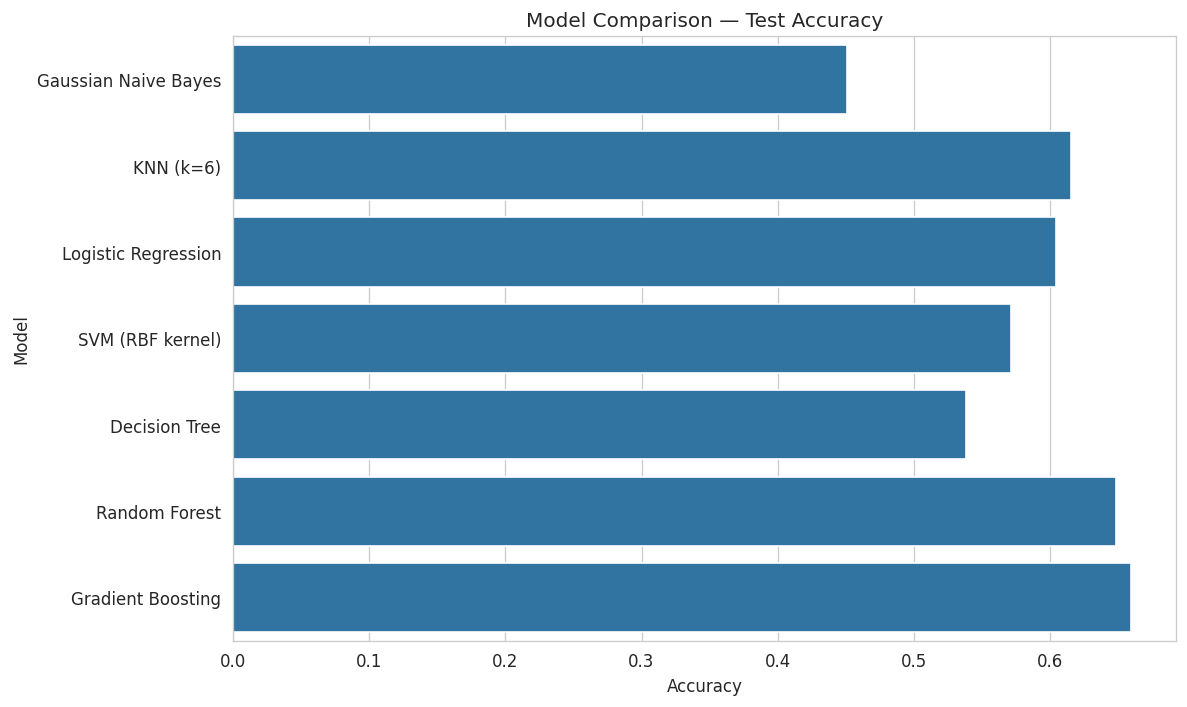

In [57]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=all_results,
    x="Test Accuracy",
    y="Model"
)

plt.title("Model Comparison — Test Accuracy")
plt.xlabel("Accuracy")
plt.ylabel("Model")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "model_comparison_test_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

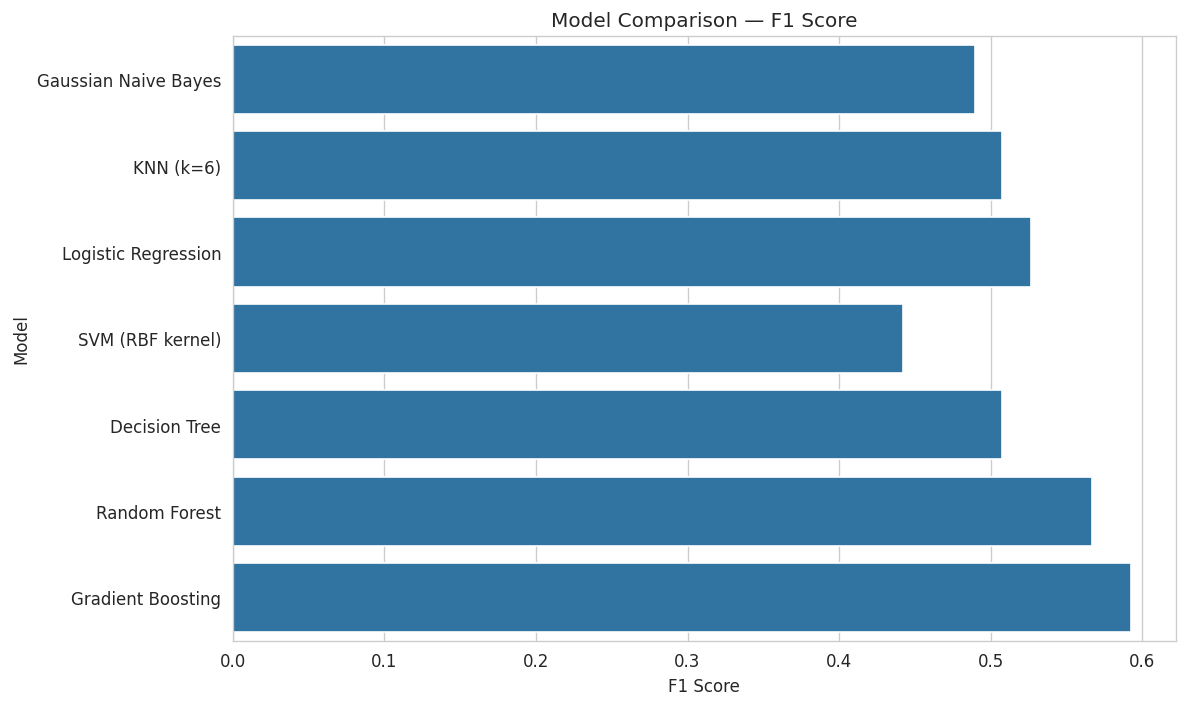

In [58]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=all_results,
    x="Test F1 Score",
    y="Model"
)

plt.title("Model Comparison — F1 Score")
plt.xlabel("F1 Score")
plt.ylabel("Model")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "model_comparison_f1_score.png", dpi=300, bbox_inches="tight")
plt.show()

In [59]:
best_model = all_results.sort_values(
    by="Test Accuracy",
    ascending=False
).iloc[0]

best_model

,6
Model,Gradient Boosting
Train Accuracy,1.0
Test Accuracy,0.659341
Test Precision,0.583894
Test Recall,0.659341
Test F1 Score,0.592639


In [60]:
best_model_name = ranking.iloc[0]["Model"]
best_accuracy = ranking.iloc[0]["Test Accuracy"]

print(f"Best performing model: {best_model_name}")
print(f"Test accuracy: {best_accuracy:.3f}")

Best performing model: Gradient Boosting
Test accuracy: 0.659


### Final Results and Discussion

The comparative analysis of multiple machine learning algorithms reveals several important insights.

1. **Ensemble methods achieved the strongest performance**

   Random Forest and Gradient Boosting outperformed simpler models such as Naive Bayes and single decision trees.

2. **Gradient Boosting produced the best overall performance**

   With a test accuracy of approximately **0.66**, Gradient Boosting provided the strongest predictive performance among all evaluated models.

3. **Tree-based ensemble methods are well suited for tabular biomedical datasets**

   These models effectively capture nonlinear relationships and interactions between ECG measurements.

4. **Class imbalance remains a significant challenge**

   Many arrhythmia classes contain very few observations, which limits classification performance and leads to strong dominance of the majority class.

Overall, the results demonstrate that ensemble machine learning models can effectively leverage physiological ECG features to support automated arrhythmia classification.

## Conclusion

This project explored multiple machine learning approaches for the classification of cardiac arrhythmias using ECG-derived features.

The workflow included:

- data preprocessing and feature selection
- exploratory data analysis
- training and evaluation of several classification algorithms
- comparison of model performance

Among the evaluated methods, **Gradient Boosting** and **Random Forest** achieved the best predictive performance, highlighting the effectiveness of ensemble learning methods for structured medical datasets.

Future work could explore:

- hyperparameter optimization
- techniques for handling class imbalance
- dimensionality reduction
- deep learning approaches for ECG signal analysis

Despite the challenges posed by limited data and class imbalance, the results demonstrate that machine learning models can extract meaningful patterns from ECG measurements and assist in arrhythmia detection.

## Key Takeaways

This project evaluated multiple machine learning approaches for arrhythmia classification using ECG-derived features.

Key findings:

• Ensemble models outperformed simpler algorithms  
• Gradient Boosting achieved the best performance (~0.66 test accuracy)  
• Tree-based models effectively captured nonlinear relationships between ECG features  
• Class imbalance remains a major challenge in arrhythmia classification

These results demonstrate that ensemble learning methods are well suited for structured biomedical datasets and can support automated ECG interpretation.